### Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

font_path = "C:/Windows/Fonts/malgun.ttf"

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

In [37]:
BASE_DIR = Path("..")

train = pd.read_csv(BASE_DIR / "data" / "ratings_train.txt", sep="\t")
train = train.dropna()

#### Review Length

In [38]:
train["length"] = train["document"].astype(str).apply(len)

In [39]:
train["length"].describe()

count    149995.000000
mean         35.204527
std          29.531890
min           1.000000
25%          16.000000
50%          27.000000
75%          42.000000
max         146.000000
Name: length, dtype: float64

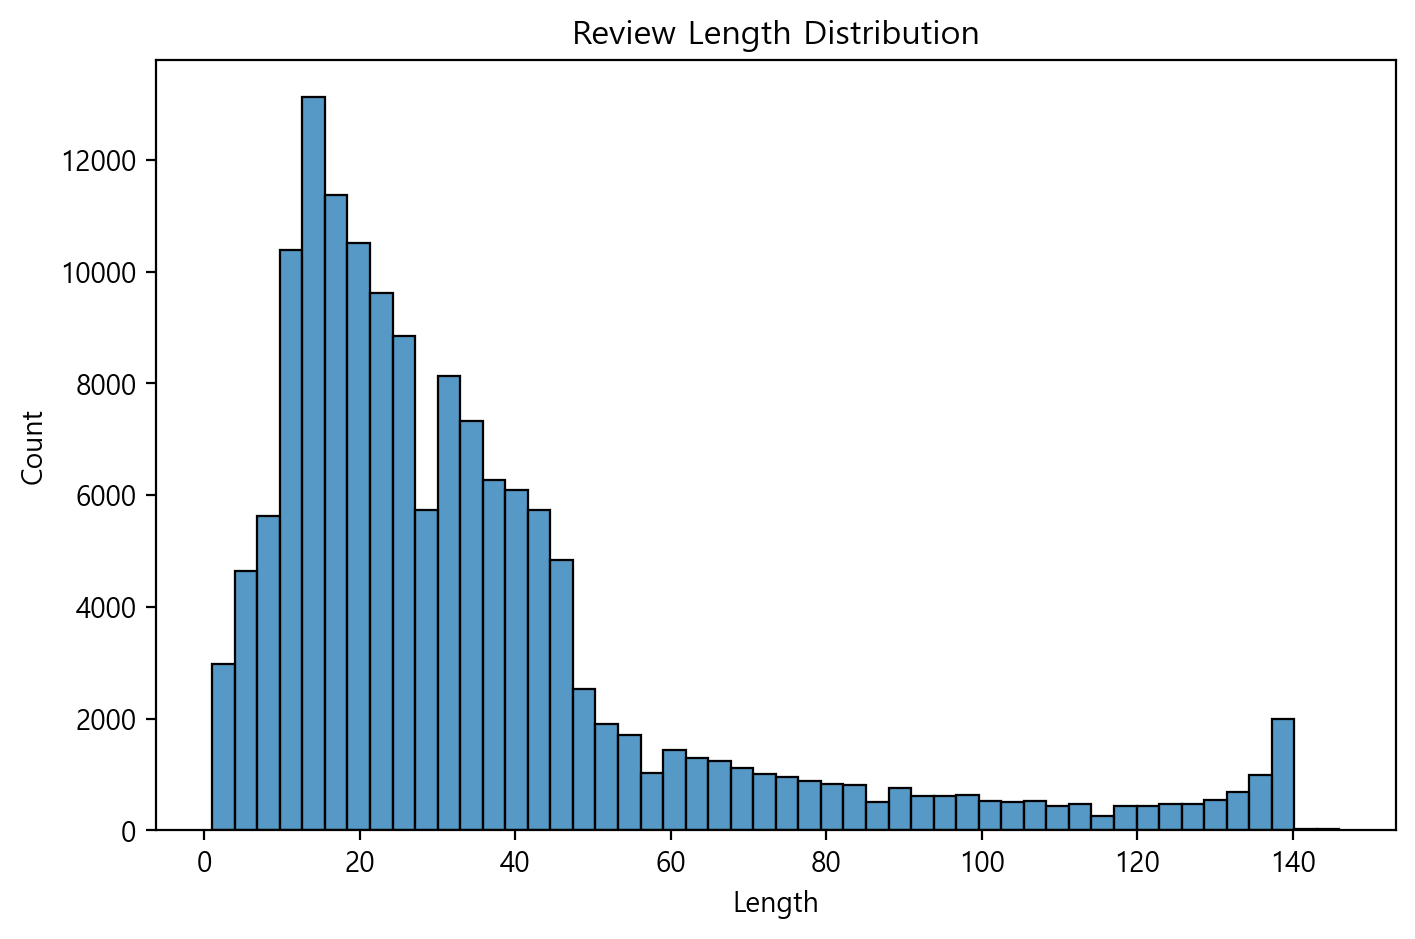

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(train["length"], bins=50)


plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

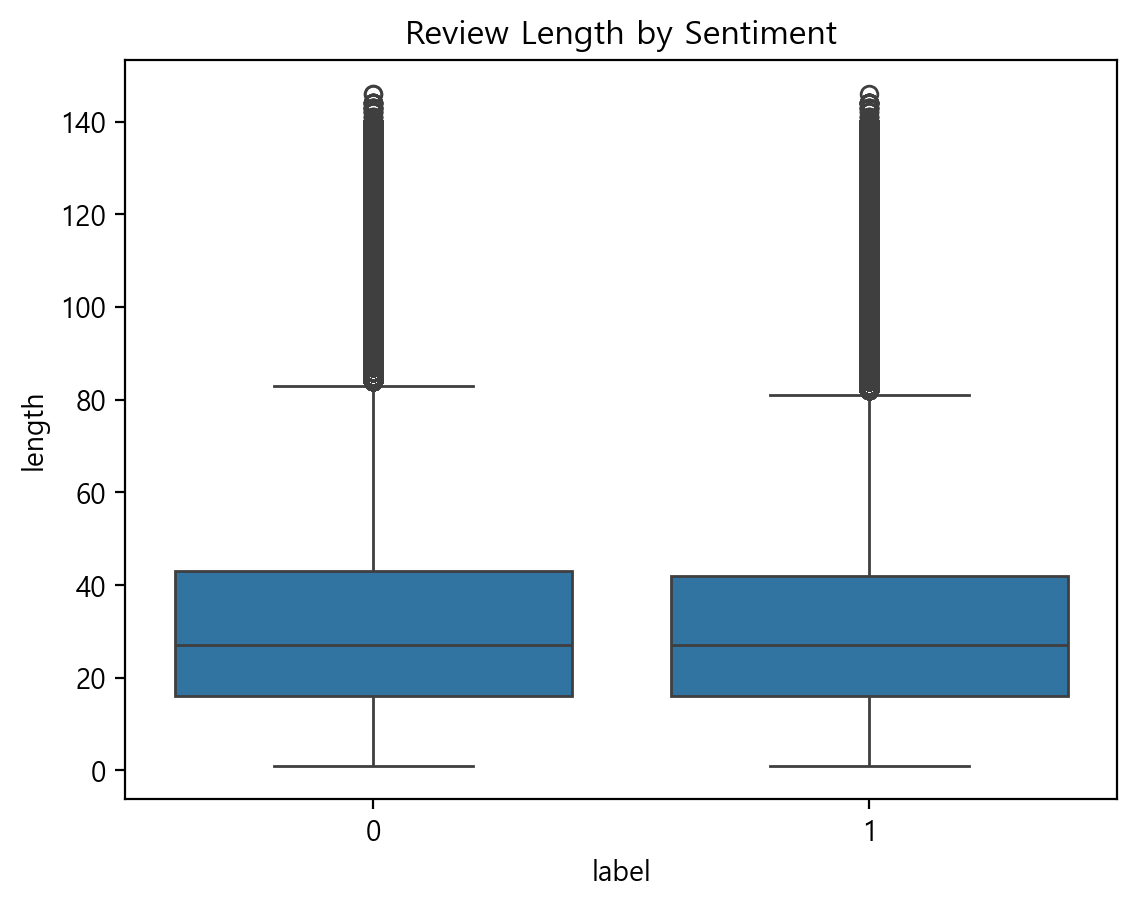

In [52]:
sns.boxplot(x="label", y="length", data=train)
plt.title("Review Length by Sentiment")
plt.show()

#### Word Count 

In [41]:
train["word_count"] = train["document"].apply(lambda x: len(x.split()))

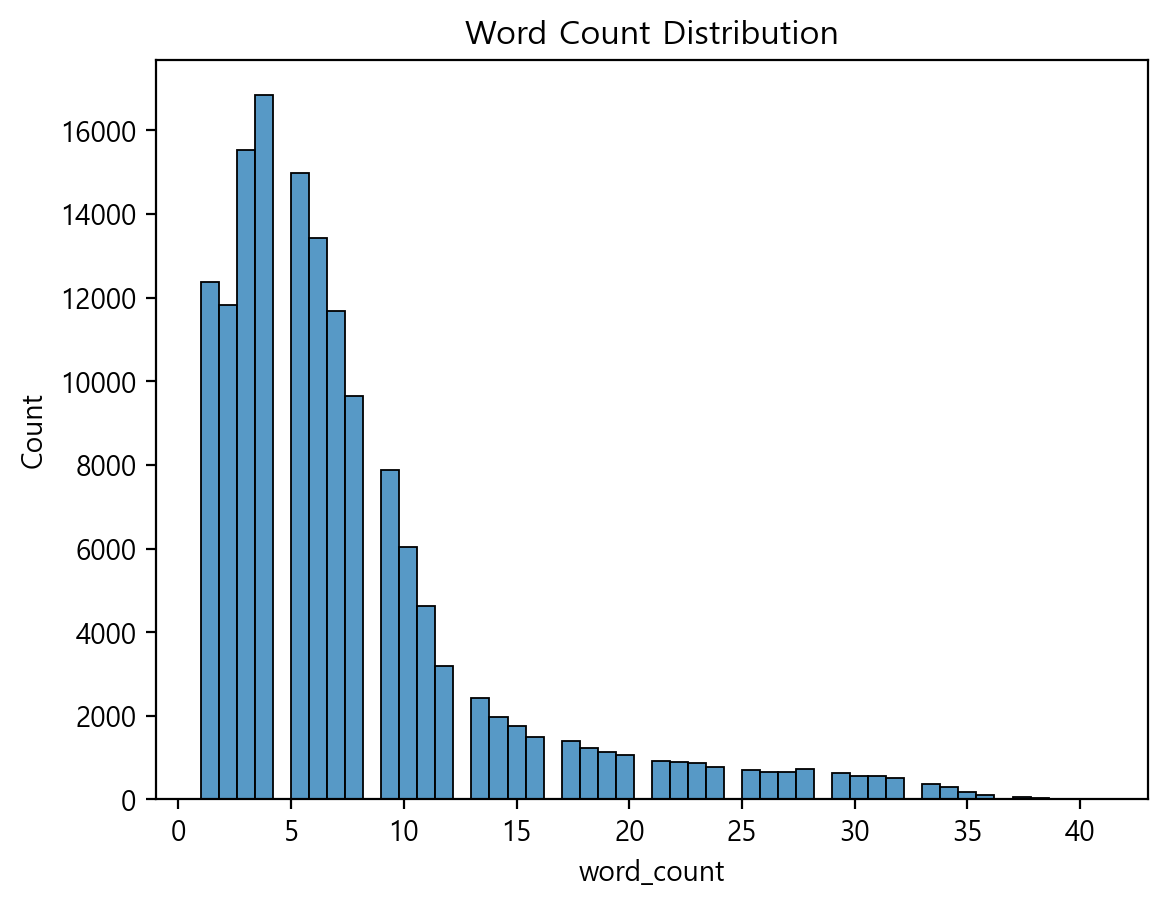

In [42]:
sns.histplot(train["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

### All words

In [43]:
all_words = " ".join(train["document"]).split()
counter = Counter(all_words)

counter.most_common(20)

[('영화', 10825),
 ('너무', 8239),
 ('정말', 7791),
 ('진짜', 5929),
 ('이', 5059),
 ('영화.', 3598),
 ('왜', 3285),
 ('더', 3260),
 ('이런', 3249),
 ('그냥', 3237),
 ('수', 2945),
 ('영화를', 2759),
 ('잘', 2644),
 ('다', 2615),
 ('보고', 2557),
 ('좀', 2449),
 ('영화는', 2426),
 ('그', 2421),
 ('영화가', 2418),
 ('본', 2298)]

#### Positive / Negative Word

In [44]:
pos = train[train["label"] == 1]
neg = train[train["label"] == 0]

In [45]:
pos_words = " ".join(pos["document"]).split()
neg_words = " ".join(neg["document"]).split()

In [46]:
Counter(pos_words).most_common(20)

[('영화', 5580),
 ('정말', 5291),
 ('너무', 4352),
 ('진짜', 2885),
 ('이', 2802),
 ('수', 2051),
 ('최고의', 2033),
 ('영화.', 1936),
 ('잘', 1935),
 ('더', 1816),
 ('보고', 1589),
 ('본', 1444),
 ('영화를', 1430),
 ('그', 1395),
 ('이런', 1382),
 ('있는', 1274),
 ('다시', 1274),
 ('좋은', 1219),
 ('ㅋㅋ', 1210),
 ('재밌게', 1177)]

In [47]:
Counter(neg_words).most_common(20)

[('영화', 5245),
 ('너무', 3887),
 ('진짜', 3044),
 ('정말', 2500),
 ('그냥', 2384),
 ('이', 2257),
 ('왜', 2184),
 ('이런', 1867),
 ('영화.', 1662),
 ('다', 1553),
 ('좀', 1532),
 ('이건', 1463),
 ('더', 1444),
 ('영화는', 1413),
 ('영화를', 1329),
 ('영화가', 1261),
 ('쓰레기', 1234),
 ('이게', 1232),
 ('없는', 1225),
 ('내가', 1081)]

#### WordCloud

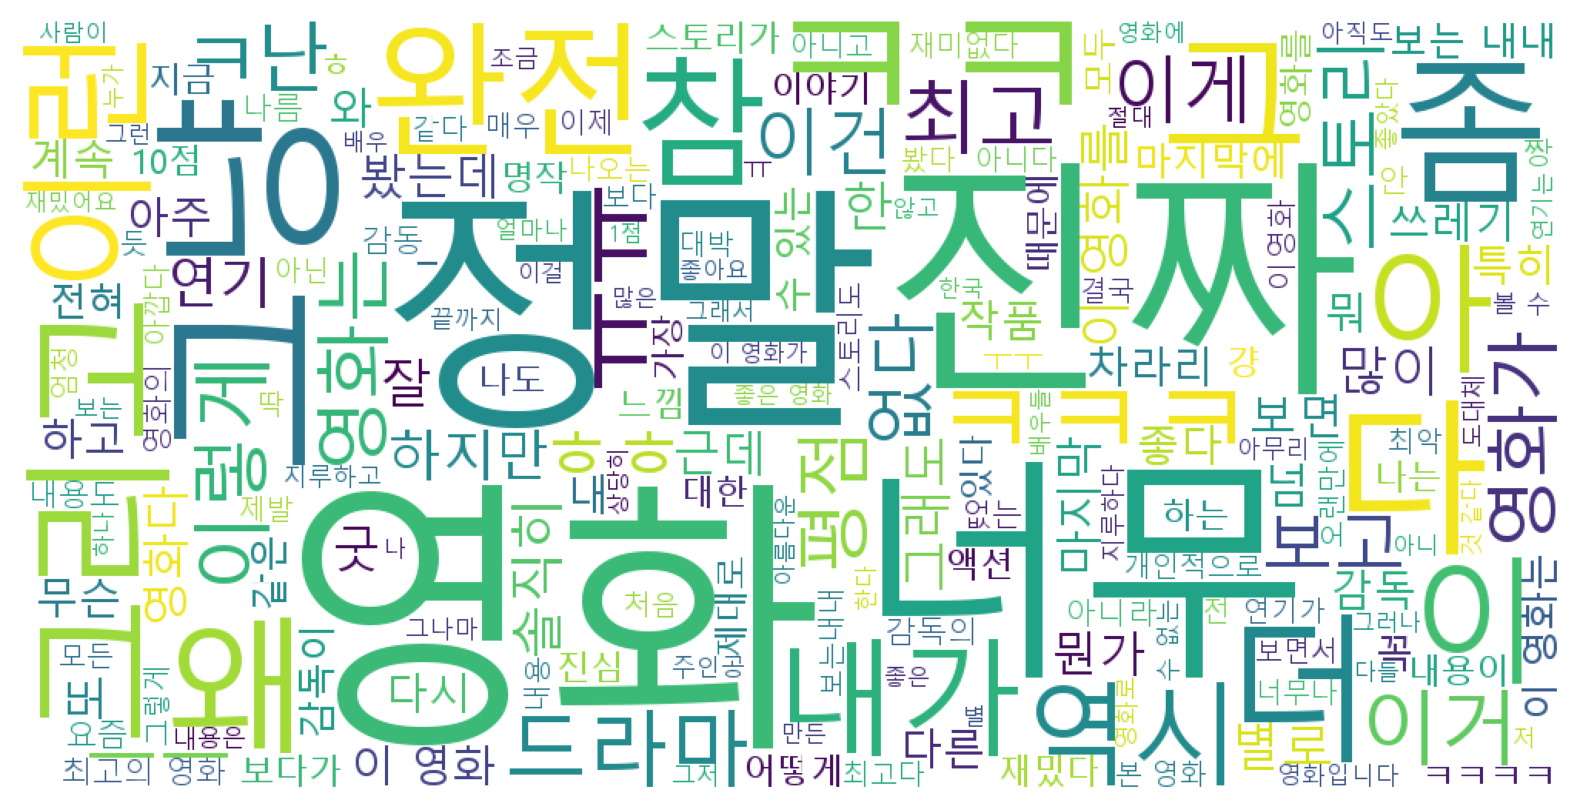

In [56]:
text = " ".join(train["document"].astype(str))

wc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    width=1000,
    height=500,
    max_words=200
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")

plt.show()

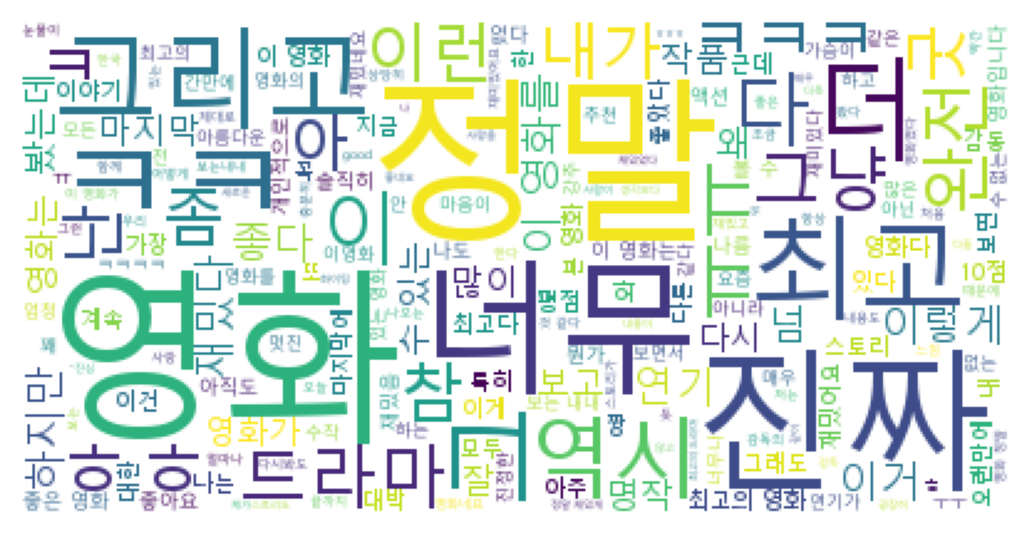

In [58]:
pos_text = " ".join(pos["document"].astype(str))

wc_pos = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white"
).generate(pos_text)

plt.imshow(wc_pos)
plt.axis("off")
plt.show()

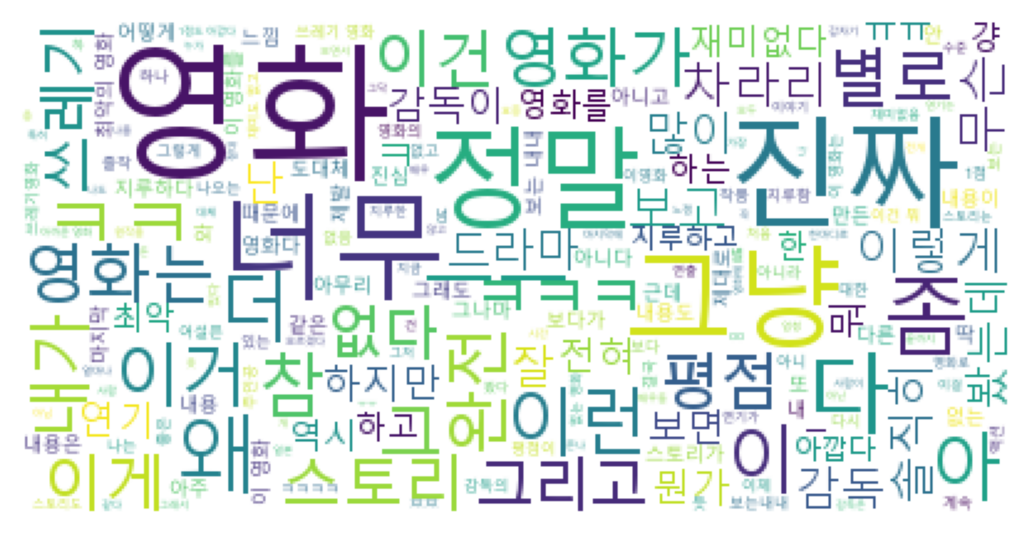

In [60]:
neg_text = " ".join(neg["document"].astype(str))

wc_neg = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white"
).generate(neg_text)

plt.imshow(wc_neg)
plt.axis("off")
plt.show()